In [1]:
# ===== Colab 初始化設定 =====
from google.colab import drive
drive.mount('/content/drive')

# 切換到你的專案 test 資料夾（ml_train_ranker.ipynb 所在位置）
import os
os.chdir("/content/drive/MyDrive/Machine Learning and FinTech/Final Project/ml-crypto/test")

# 確認目前所在資料夾與相對位置是否正確
import pathlib
print("Current working directory:", os.getcwd())
print("Parent folder contents:", os.listdir(".."))  # 應該能看到 data/
print("Curated folder contents:", os.listdir("../data/curated"))

Mounted at /content/drive
Current working directory: /content/drive/MyDrive/Machine Learning and FinTech/Final Project/ml-crypto/test
Parent folder contents: ['requirements.txt', 'README.md', 'test', 'src', 'scripts', 'storage', 'notebooks', 'data', 'config', 'models']
Curated folder contents: ['universe_top30_annual.parquet', 'rf_weekly.parquet', 'prices_weekly.parquet', 'factors_weekly.parquet', 'fmp_weekly.parquet', 'ml_preds_weekly.parquet', 'ml_preds_weekly_tft.parquet', 'backtest_ml_longshort.parquet', 'ml_preds_weekly_three.parquet']


In [2]:
# portfolio_backtest — cross-sectional long/short weekly backtest with risk controls

from pathlib import Path
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt

ROOT = Path("..")
CUR  = ROOT / "data" / "curated"
MET  = ROOT / "data" / "metrics"
for p in [CUR, MET]: p.mkdir(parents=True, exist_ok=True)

# 檔案
PRED_FP = CUR / "ml_preds_weekly_three.parquet"  # 07 的輸出
FACT_FP = CUR / "factors_weekly.parquet"   # 含 ret_simple_weekly / rf_weekly
FMP_FP  = CUR / "fmp_weekly.parquet"       # 含 CMKT（及 CSMB/CMOM 如有）

# 主要回測/風控參數（可自行調整）
PARAMS = dict(
    Q=5,                        # 分位數（Top/Bottom 分組）
    GROSS_LEV=1.0,              # |w_long| + |w_short|
    MAX_W_PER_ASSET=0.10,       # 單名額上限
    TC_BPS=10,                  # 單邊交易成本（bps）
    MAX_TURNOVER_ASSET=0.30,    # 單名額單週最大換手
    VOL_TARGET_ANN=0.30,        # 年化波動目標
    VOL_ROLL_WEEKS=26,          # 滾動視窗（vol targeting）
    BETA_ROLL_WEEKS=52,         # 估對 CMKT 的 beta 視窗
    BETA_NEUTRAL=True,          # 是否 β-neutral
    VOL_TARGET=True             # 是否啟用 vol targeting
)

print("params:", json.dumps(PARAMS, indent=2))

params: {
  "Q": 5,
  "GROSS_LEV": 1.0,
  "MAX_W_PER_ASSET": 0.1,
  "TC_BPS": 10,
  "MAX_TURNOVER_ASSET": 0.3,
  "VOL_TARGET_ANN": 0.3,
  "VOL_ROLL_WEEKS": 26,
  "BETA_ROLL_WEEKS": 52,
  "BETA_NEUTRAL": true,
  "VOL_TARGET": true
}


In [3]:
# 預測（ml 輸出）
pred = pd.read_parquet(PRED_FP).copy()
pred["date_week"] = pd.to_datetime(pred["date_week"]).dt.tz_localize(None)

# 事後實際報酬（下一週報酬將以當期 ret 欄位代表；07 的 y_fwd1 就是下一週超額報酬，用來評估 RankIC）
fact = pd.read_parquet(FACT_FP).copy()
fact["date_week"] = pd.to_datetime(fact["date_week"]).dt.tz_localize(None)
if "rf_weekly" not in fact.columns:
    fact["rf_weekly"] = 0.0

# 資產鍵（優先使用已存在的欄位）
ASSET_KEYS = ["market", "symbol", "coingecko_id"]
asset_key = next((k for k in ASSET_KEYS if k in pred.columns), None)
if asset_key is None:
    asset_key = next((k for k in ASSET_KEYS if k in fact.columns), None)
if asset_key is None:
    asset_key = "_asset"
    pred["_asset"] = "asset_0"
    fact["_asset"] = "asset_0"

# 統一 symbol 大寫（若存在）
for df_ in [pred, fact]:
    if "symbol" in df_.columns:
        df_["symbol"] = df_["symbol"].astype(str).str.upper()

# 合併預測與實際（當期 ret 即持有 t->t+1 週的實際報酬；07 已將目標對齊為 y_fwd1）
cols_keep = ["date_week", asset_key, "ret_simple_weekly", "rf_weekly"]
m = pred.merge(fact[cols_keep], on=["date_week", asset_key], how="left") \
        .rename(columns={"ret_simple_weekly": "ret"})
m = m.sort_values([asset_key, "date_week"]).reset_index(drop=True)

print("merged rows:", len(m), "| weeks:", m["date_week"].nunique(), "| assets:", m[asset_key].nunique())
display(m.head(3))

merged rows: 4754 | weeks: 325 | assets: 31


,date_week,market,y_pred,ret,rf_weekly
0,2019-07-07,ADA/USDT,0.444444,-0.031121,0.0
1,2019-07-14,ADA/USDT,0.911111,-0.256838,0.0
2,2019-07-21,ADA/USDT,0.844444,0.031065,0.0


In [4]:
# 讀因子（至少要有 CMKT）
fmp = pd.read_parquet(FMP_FP).copy()
fmp["date_week"] = pd.to_datetime(fmp["date_week"]).dt.tz_localize(None)
if "CMKT" not in fmp.columns:
    raise SystemExit("fmp_weekly.parquet 缺少 CMKT 欄位。請先用 build_fmp.py 產生因子模擬組合。")

cmkt = fmp[["date_week", "CMKT"]].dropna()

# ---- 基準序列（BTC 若缺則用 CMKT） ----
bench_df = fmp[["date_week"]].copy()
if "BTC" in fmp.columns:
    bench_df["bench_ret"] = fmp["BTC"]
    bench_label = "BTC buy & hold"
else:
    bench_df["bench_ret"] = fmp["CMKT"]
    bench_label = "CMKT buy & hold"
bench_df = bench_df.dropna(subset=["bench_ret"])
# --------------------------------------


def rolling_beta_to_cmkt(df_one: pd.DataFrame, win: int) -> pd.DataFrame:
    """
    OLS：ret_i ~ a + b * CMKT，在每個資產內用過去 win 週估 β。
    回傳 columns: date_week, beta_cmkt
    """
    out = []
    g = df_one.merge(cmkt, on="date_week", how="left").dropna(subset=["ret","CMKT"]).copy()
    for i in range(win, len(g)+1):
        sub = g.iloc[i-win:i]
        x = sub["CMKT"].values
        y = sub["ret"].values
        X = np.vstack([np.ones_like(x), x]).T
        try:
            b = np.linalg.lstsq(X, y, rcond=None)[0][1]
        except Exception:
            b = np.nan
        out.append({"date_week": sub["date_week"].iloc[-1], "beta_cmkt": b})
    return pd.DataFrame(out)

# 估各資產滾動 β（僅在需要 β-neutral 時）
beta_df = []
if PARAMS["BETA_NEUTRAL"]:
    for aid, g in m.groupby(asset_key):
        rb = rolling_beta_to_cmkt(g[[asset_key, "date_week", "ret"]].copy(), win=PARAMS["BETA_ROLL_WEEKS"])
        if not rb.empty:
            rb[asset_key] = aid
            beta_df.append(rb)
    beta_df = pd.concat(beta_df, ignore_index=True) if beta_df else pd.DataFrame(columns=["date_week","beta_cmkt",asset_key])
else:
    beta_df = pd.DataFrame(columns=["date_week","beta_cmkt",asset_key])

print("beta rows:", len(beta_df))
display(beta_df.head(3))

beta rows: 3300


,date_week,beta_cmkt,market
0,2020-06-28,0.196860,ADA/USDT
1,2020-07-05,0.258111,ADA/USDT
2,2020-07-12,0.276750,ADA/USDT


In [6]:
def beta_neutralize(w: pd.Series, beta: pd.Series) -> pd.Series:
    """
    調整權重 w 使 Σ w_i β_i = 0；若 β 不足或分母太小，回傳原 w。
    """
    beta = beta.reindex(w.index).fillna(0.0)
    num = float((w * beta).sum())
    den = float((beta ** 2).sum())
    if den <= 1e-12:
        return w
    lam = num / den
    return w - lam * beta

def apply_turnover_cap(w_prev: pd.Series, w_target: pd.Series, cap: float) -> pd.Series:
    """
    對單一名額的權重變化 |Δw_i| 套上上限 cap，回傳新權重。
    """
    w_prev = w_prev.reindex(w_target.index).fillna(0.0)
    delta = (w_target - w_prev).clip(-cap, cap)
    return w_prev + delta, delta

def sharpe_annual(weekly_ret: pd.Series) -> float:
    mu = weekly_ret.mean() * 52
    sd = weekly_ret.std() * np.sqrt(52)
    return float(mu / sd) if sd > 1e-12 else np.nan

def max_drawdown(cum: pd.Series) -> float:
    peak = cum.cummax()
    dd = (cum/peak - 1.0)
    return float(dd.min())

def summarize_bt(df: pd.DataFrame, col: str = "ret_net_vt") -> pd.Series:
    s = {}
    s["weeks"]        = int(len(df))
    s["ann_return"]   = df[col].mean() * 52
    s["ann_vol"]      = df[col].std() * np.sqrt(52)
    s["sharpe"]       = sharpe_annual(df[col])
    s["mdd"]          = max_drawdown((1 + df[col]).cumprod())
    s["avg_turnover"] = df["turnover"].mean()
    s["avg_tc_bps"]   = df["tc"].mean() * 1e4
    s["beta_cmkt"]    = df["beta_cmkt_port"].mean() if "beta_cmkt_port" in df.columns else np.nan
    return pd.Series(s)


In [7]:
def backtest_from_pred(
    pred_df: pd.DataFrame,
    params: dict,
    asset_key: str,
    beta_df: pd.DataFrame = None,
    cmkt_df: pd.DataFrame = None
) -> pd.DataFrame:
    """
    以預測分數 y_pred 建立長短多空組合，回傳逐週績效表。
    pred_df 需要欄位：date_week, asset_key, y_pred, ret（當週實際報酬）
    """
    Q = params["Q"]; GROSS = params["GROSS_LEV"]; MAX_W = params["MAX_W_PER_ASSET"]
    TC_BPS = params["TC_BPS"]; MAX_TO = params["MAX_TURNOVER_ASSET"]
    VOL_TGT = params["VOL_TARGET_ANN"]; VOL_WIN = params["VOL_ROLL_WEEKS"]
    DO_BETA = params["BETA_NEUTRAL"]; DO_VT = params["VOL_TARGET"]

    all_dates = sorted(pred_df["date_week"].unique())
    w_prev = pd.Series(dtype=float)
    rows = []

    for d in all_dates:
        g = pred_df[pred_df["date_week"] == d].dropna(subset=["y_pred","ret"]).copy()
        if len(g) < 10:
            continue

        # 依 y_pred 分位數切 Top / Bottom
        try:
            q = pd.qcut(g["y_pred"], Q, labels=False, duplicates="drop")
        except Exception:
            # 若 qcut 失敗（樣本少或重複多），改用 rank 百分位
            rk = g["y_pred"].rank(method="average", pct=True)
            q = np.floor(rk * Q).clip(0, Q-1).astype(int)

        g = g.assign(bucket=q)
        long  = g[g["bucket"] == g["bucket"].max()]
        short = g[g["bucket"] == g["bucket"].min()]
        if len(long) == 0 or len(short) == 0:
            continue

        # 初始等權（長為 +，短為 −），並做單名額上限
        w_long  = pd.Series(GROSS/2 / len(long), index=long[asset_key])
        w_short = pd.Series(-GROSS/2 / len(short), index=short[asset_key])
        w = pd.concat([w_long, w_short]).groupby(level=0).sum()
        w = w.clip(-MAX_W, MAX_W)

        # β-neutral（若啟用）
        if DO_BETA and beta_df is not None and not beta_df.empty:
            beta_now = beta_df[beta_df["date_week"] == d].set_index(asset_key)["beta_cmkt"]
            w = beta_neutralize(w, beta_now)

        # 正規化總槓桿回到 GROSS
        gross = w.abs().sum()
        if gross > 1e-12:
            w = w * (GROSS / gross)

        # turnover cap
        w, delta = apply_turnover_cap(w_prev.reindex(w.index).fillna(0.0), w, MAX_TO)

        # 再正規化（避免 cap 後槓桿漂移）
        gross = w.abs().sum()
        if gross > 1e-12:
            w = w * (GROSS / gross)

        # 交易成本（對當期調整量 delta 收費）
        tc = float(delta.abs().sum()) * (TC_BPS / 1e4)

        # 本週持有報酬
        r = g.set_index(asset_key)["ret"].reindex(w.index).fillna(0.0)
        ret_gross = float((w * r).sum())
        ret_net   = ret_gross - tc

        # 組合 β（監控用）
        beta_now = None
        if DO_BETA and beta_df is not None and not beta_df.empty:
            beta_now = beta_df[beta_df["date_week"] == d].set_index(asset_key)["beta_cmkt"].reindex(w.index)
            beta_port = float((w * beta_now.fillna(0.0)).sum())
        else:
            beta_port = np.nan

        rows.append({
            "date_week": d,
            "ret_gross": ret_gross,
            "ret_net": ret_net,
            "turnover": float(delta.abs().sum()),
            "tc": tc,
            "n_long": int((w>0).sum()),
            "n_short": int((w<0).sum()),
            "beta_cmkt_port": beta_port
        })

        w_prev = w.copy()

    port = pd.DataFrame(rows).sort_values("date_week").reset_index(drop=True)

    # Vol targeting（若啟用）
    if DO_VT and not port.empty:
        target_sigma_w = VOL_TGT / np.sqrt(52)
        port["vol_scale"] = 1.0
        for i in range(VOL_WIN, len(port)):
            sigma = port["ret_net"].iloc[i-VOL_WIN:i].std()
            if pd.notna(sigma) and sigma > 1e-8:
                scale = target_sigma_w / sigma
                scale = float(np.clip(scale, 0.5, 2.0))  # 安全夾
            else:
                scale = 1.0
            port.loc[i, "vol_scale"] = scale
        port["ret_net_vt"] = port["ret_net"] * port["vol_scale"]
    else:
        port["vol_scale"] = 1.0
        port["ret_net_vt"] = port["ret_net"]

    return port

,"Strategy (net, vt)",CMKT buy & hold
weeks,325.000000,325.000000
ann_return,1516.156062,411.313571
ann_vol,3790.880860,1026.646912
sharpe,0.399948,0.400638
mdd,-0.669147,-0.655353
avg_turnover,0.706675,0.000000
avg_tc_bps,7.066751,0.000000
beta_cmkt,0.000130,NaN


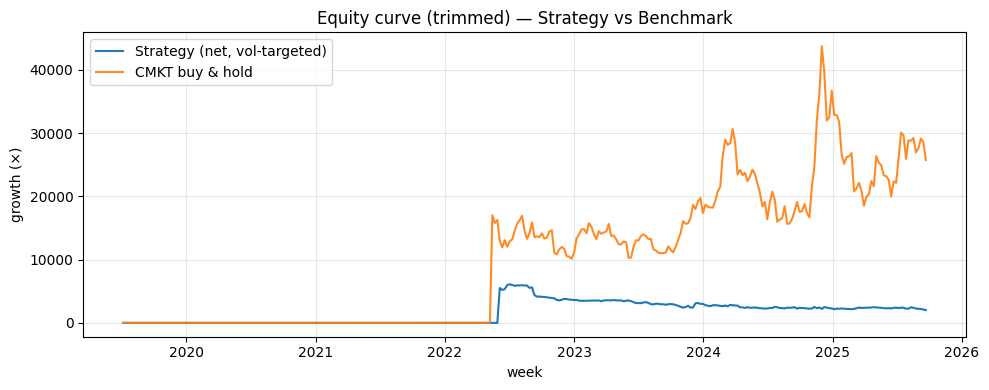

saved backtest: ../data/curated/backtest_ml_longshort.parquet
saved summary : ../data/metrics/backtest_summary_20251205.json


,date_week,ret_gross,ret_net,turnover,tc,n_long,n_short,beta_cmkt_port,vol_scale,ret_net_vt
0,2019-07-07,-0.049895,-0.050895,1.000000,0.001000,3,3,0.0,1.0,-0.050895
1,2019-07-14,-0.037735,-0.038068,0.333333,0.000333,3,3,0.0,1.0,-0.038068
2,2019-07-21,-0.007415,-0.007915,0.500000,0.000500,3,3,0.0,1.0,-0.007915
3,2019-07-28,0.037640,0.037140,0.500000,0.000500,3,3,0.0,1.0,0.037140
4,2019-08-04,0.007440,0.006773,0.666667,0.000667,3,3,0.0,1.0,0.006773


In [8]:
# 基準回測（使用 PARAMS）
port = backtest_from_pred(
    pred_df=m.rename(columns={"y_pred":"y_pred"}),  # 直接用 m 的 y_pred
    params=PARAMS,
    asset_key=asset_key,
    beta_df=beta_df,
    cmkt_df=cmkt
)

if port.empty:
    raise SystemExit("回測組合為空，請檢查預測檔或參數（樣本數是否太少？）")

# === Summary + Trimmed equity with BTC/CMKT overlay (drop-in replacement for Cell 6) ===

# 0) 若沒 bench_df，就用 FMP 檔重建一次
if "bench_df" not in globals():
    fmp = pd.read_parquet(FMP_FP).copy()
    fmp["date_week"] = pd.to_datetime(fmp["date_week"]).dt.tz_localize(None)
    bench_df = fmp[["date_week"]].copy()
    if "BTC" in fmp.columns:
        bench_df["bench_ret"] = fmp["BTC"]
        bench_label = "BTC buy & hold"
    else:
        bench_df["bench_ret"] = fmp["CMKT"]
        bench_label = "CMKT buy & hold"
    bench_df = bench_df.dropna(subset=["bench_ret"])
else:
    # 若你在 Cell 3 已建過 bench_df，這裡補 bench_label
    if "bench_label" not in globals():
        bench_label = "BTC buy & hold" if "BTC" in pd.read_parquet(FMP_FP).columns else "CMKT buy & hold"

# 1) 從「第一個有部位」的週開始裁切（若沒有 n_long/n_short，就用第一個非零報酬）
if {"n_long","n_short"}.issubset(port.columns):
    mask_active = (port["n_long"] > 0) | (port["n_short"] > 0)
else:
    mask_active = port["ret_net_vt"].abs() > 1e-12

if not mask_active.any():
    raise SystemExit("策略在樣本內沒有產生任何部位/報酬，請檢查輸入預測與參數。")

first_active_date = port.loc[mask_active, "date_week"].min()
port_trim = port[port["date_week"] >= first_active_date].copy()

# 2) 與基準對齊（只用重疊期間）
plot_df = (
    port_trim[["date_week", "ret_net_vt"]]
    .merge(bench_df.rename(columns={"date_week":"date_week_bench"}),
           left_on="date_week", right_on="date_week_bench", how="inner")
    .drop(columns=["date_week_bench"])
    .rename(columns={"bench_ret":"ret_bench"})
    .dropna(subset=["ret_net_vt","ret_bench"])
    .sort_values("date_week")
    .reset_index(drop=True)
)
if plot_df.empty:
    raise SystemExit("沒有與基準重疊的週期可畫圖與統計，請檢查 FMP 與回測日期。")

# 3) Summary：策略 vs 基準（同一裁切期間）
sum_strategy = summarize_bt(port_trim, col="ret_net_vt")
bench_for_sum = plot_df[["ret_bench"]].rename(columns={"ret_bench":"ret_net_vt"}).copy()
bench_for_sum["turnover"] = 0.0
bench_for_sum["tc"] = 0.0
sum_bench = summarize_bt(bench_for_sum, col="ret_net_vt")

sum_tbl = pd.concat(
    [sum_strategy.rename("Strategy (net, vt)"),
     sum_bench.rename(bench_label)],
    axis=1
)
display(sum_tbl)

# 4) 權益曲線（從裁切後第一週開始；兩條都正規化到 1）
plot_df["equity_port"]  = (1.0 + plot_df["ret_net_vt"]).cumprod()
plot_df["equity_bench"] = (1.0 + plot_df["ret_bench"]).cumprod()
plot_df["equity_port"]  /= plot_df["equity_port"].iloc[0]
plot_df["equity_bench"] /= plot_df["equity_bench"].iloc[0]

plt.figure(figsize=(10,4))
plt.plot(plot_df["date_week"], plot_df["equity_port"],  label="Strategy (net, vol-targeted)")
plt.plot(plot_df["date_week"], plot_df["equity_bench"], label=bench_label, alpha=0.9)
plt.title("Equity curve (trimmed) — Strategy vs Benchmark")
plt.xlabel("week"); plt.ylabel("growth (×)")
plt.grid(True, alpha=0.3); plt.legend()
plt.tight_layout(); plt.show()


# 儲存回測明細與摘要
OUT_BT = CUR / "backtest_ml_longshort.parquet"
port.to_parquet(OUT_BT, index=False)
OUT_SUM = MET / f"backtest_summary_{pd.Timestamp.utcnow().strftime('%Y%m%d')}.json"
with open(OUT_SUM, "w") as f:
    json.dump({k: float(v) if isinstance(v, (np.floating,)) else v for k,v in summarize_bt(port).to_dict().items()}, f, indent=2)

print("saved backtest:", OUT_BT)
print("saved summary :", OUT_SUM)

# 顯示前幾列
display(port.head(5))


